# 5. 잔액정보 (잔액 정보) EDA

카테고리 5 = **빚이 얼마나 있나 (미결제 잔액)**. 82개 컬럼. 라벨은 회원정보(카테고리 1)에서 조인.

**사전 발견**: Segment는 이용/가치 등급(A상위~E하위) 순서형. 지금까지 **B ≈ 고소비지만 고금리·연체·선결제·포인트소진(리볼빙/위험 성향)** 프로필로 수렴 중. → 이 카테고리의 **RV(리볼빙) 잔액 · 연체 잔액**으로 B 가설을 직접 검증한다.

**컬럼 구조**: 상품별 잔액(일시불/할부/현금서비스CA/카드론/리볼빙, B0M~B5M), 월중평잔·평잔(3M/6M), RV_평균·최대잔액(3/6/12M), 연체(잔액/일수/원금/회차).
⚠️ 센티넬: 연체일수 `-999999`, 최종연체회차 `-99` (=연체 없음). `연체일자_B0M`은 99.9% 결측(연체=희귀).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False
pd.set_option('display.max_columns',200); pd.set_option('display.width',220)
import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(),'..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH='201812'; SEG_ORDER=['A','B','C','D','E']
SEG_COLORS={'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812 잔액) + 라벨 조인

In [2]:
f5 = glob.glob(os.path.join(ROOT,'train','5.*',f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f5)
lbl = pd.read_parquet(glob.glob(os.path.join(ROOT,'train','1.*',f'{MONTH}_*.parquet'))[0], columns=['ID','Segment'])
df = df.merge(lbl, on='ID', how='left')
assert df['Segment'].notna().all()
print('shape:', df.shape); df.head(3)

shape: (400000, 83)


,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,월중평잔_CA_B0M,카드론잔액_최종경과월,연체일자_B0M,연체잔액_B0M,연체잔액_일시불_B0M,연체잔액_할부_B0M,연체잔액_현금서비스_B0M,연체잔액_카드론_B0M,연체잔액_대환론_B0M,잔액_현금서비스_B1M,잔액_현금서비스_B2M,잔액_카드론_B1M,잔액_카드론_B2M,잔액_카드론_B3M,잔액_카드론_B4M,잔액_카드론_B5M,잔액_할부_B1M,잔액_할부_B2M,잔액_일시불_B1M,잔액_일시불_B2M,연체일수_B1M,연체일수_B2M,연체원금_B1M,연체원금_B2M,연체일수_최근,연체원금_최근,최종연체회차,매각잔액_B1M,최종연체개월수_R15M,RV_평균잔액_R12M,RV_최대잔액_R12M,RV_평균잔액_R6M,RV_최대잔액_R6M,RV_평균잔액_R3M,RV_최대잔액_R3M,RV잔액이월횟수_R6M,RV잔액이월횟수_R3M,잔액_할부_유이자_B0M,잔액_할부_무이자_B0M,잔액_할부_해외_B0M,연체잔액_일시불_해외_B0M,연체잔액_RV일시불_B0M,연체잔액_RV일시불_해외_B0M,연체잔액_할부_해외_B0M,연체잔액_CA_B0M,연체잔액_CA_해외_B0M,월중평잔,월중평잔_일시불,월중평잔_RV일시불,월중평잔_할부,월중평잔_CA,월중평잔_카드론,평잔_3M,평잔_일시불_3M,평잔_일시불_해외_3M,평잔_RV일시불_3M,평잔_RV일시불_해외_3M,평잔_할부_3M,평잔_할부_해외_3M,평잔_CA_3M,평잔_CA_해외_3M,평잔_카드론_3M,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M,Segment
0,201812,TRAIN_000000,687,866,24017,0,0,0,850,503,27952,0,NaN,0,0,0,0,0,0,30383,30640,0,0,0,0,0,551,580,568,554,-999999,-999999,0,0,-999999,0,0,0,0,0,0,0,0,0,0,0,0,0,866,0,0,0,0,0,0,0,17009,1035,0,478,26944,0,21343,1433,0,0,0,492,0,25849,0,0,25755,2337,0,0,0,626,0,20837,0,0,D
1,201812,TRAIN_000001,2264,1491,0,0,0,0,2222,1412,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,1488,1767,2253,2898,-999999,-999999,0,0,-999999,0,0,0,0,0,0,0,0,0,0,0,0,1491,0,0,0,0,0,0,0,0,4321,2399,2370,1323,0,0,4155,2621,0,2486,0,1883,0,0,0,0,6168,2865,0,2629,0,1937,0,0,0,0,E
2,201812,TRAIN_000002,7303,2370,21886,5380,0,0,10580,3315,26941,0,NaN,0,0,0,0,0,0,27940,27654,0,0,0,0,0,4137,3100,9797,4369,-999999,-999999,0,0,-999999,0,0,0,0,1255,4587,2926,6104,3149,6104,0,0,0,2370,0,0,0,0,0,0,0,49642,8091,7371,4582,29331,0,47611,6211,0,6187,0,5416,0,50796,0,0,84397,7522,0,6206,0,7062,0,59197,0,0,C


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

In [3]:
meta = pd.DataFrame({'dtype':df.dtypes.astype(str),'n_missing':df.isna().sum(),
    'missing_%':(df.isna().mean()*100).round(2),'nunique':df.nunique(dropna=True)})
meta.sort_values(['nunique','missing_%'])

,dtype,n_missing,missing_%,nunique
기준년월,int64,0,0.0,1
카드론잔액_최종경과월,int64,0,0.0,1
연체잔액_카드론_B0M,int64,0,0.0,1
연체잔액_대환론_B0M,int64,0,0.0,1
매각잔액_B1M,int64,0,0.0,1
...,...,...,...,...
평잔_일시불_6M,int64,0,0.0,32148
월중평잔,int64,0,0.0,48795
평잔_3M,int64,0,0.0,49466
평잔_6M,int64,0,0.0,55075


### 2-1. 버릴 후보 & 센티넬 처리

In [4]:
const_cols = meta.index[meta['nunique']<=1].tolist()
high_missing = meta.index[meta['missing_%']>=40].tolist()
print(f'상수 컬럼 {len(const_cols)}개:'); print(const_cols)
print(f'\n고결측(>=40%) {len(high_missing)}개:', high_missing)

dfx = df.copy()
# 센티넬 → NaN
for c in ['연체일수_B1M','연체일수_B2M','연체일수_최근']:
    if c in dfx: dfx.loc[dfx[c]<=-999999, c]=np.nan
if '최종연체회차' in dfx: dfx.loc[dfx['최종연체회차']<=-99,'최종연체회차']=np.nan
print('\n센티넬 처리 후 연체일수_최근 값 분포:'); print(dfx['연체일수_최근'].value_counts(dropna=False).to_string())

상수 컬럼 13개:
['기준년월', '카드론잔액_최종경과월', '연체잔액_카드론_B0M', '연체잔액_대환론_B0M', '매각잔액_B1M', '최종연체개월수_R15M', 'RV잔액이월횟수_R6M', 'RV잔액이월횟수_R3M', '연체잔액_일시불_해외_B0M', '연체잔액_RV일시불_B0M', '연체잔액_RV일시불_해외_B0M', '연체잔액_할부_해외_B0M', '연체잔액_CA_해외_B0M']

고결측(>=40%) 1개: ['연체일자_B0M']



센티넬 처리 후 연체일수_최근 값 분포:
연체일수_최근
NaN    389837
0.0      9976
1.0       187


## 3. 세그먼트별 잔액 규모 (순서형 검증)

총 평잔·상품별 잔액이 A→E로 정렬되는지.

In [5]:
rep = [c for c in ['월중평잔','평잔_3M','평잔_6M','잔액_일시불_B0M','잔액_할부_B0M',
                    '잔액_현금서비스_B0M','잔액_카드론_B0M'] if c in dfx]
print('세그먼트별 중앙값 (₩):')
print(dfx.groupby('Segment')[rep].median().reindex(SEG_ORDER).T.to_string())

세그먼트별 중앙값 (₩):


Segment             A        B        C        D       E
월중평잔          54370.0  61343.5  18538.0   9325.0  1683.0
평잔_3M         48915.5  59509.5  18698.0   9446.0  1823.0
평잔_6M         61304.0  63758.5  22285.0  11356.0  2042.0
잔액_일시불_B0M    18443.0  19817.5   7644.0   4440.0   732.0
잔액_할부_B0M      4148.5  15622.5      0.0      0.0     0.0
잔액_현금서비스_B0M      0.0      0.0      0.0      0.0     0.0
잔액_카드론_B0M        0.0      0.0      0.0      0.0     0.0


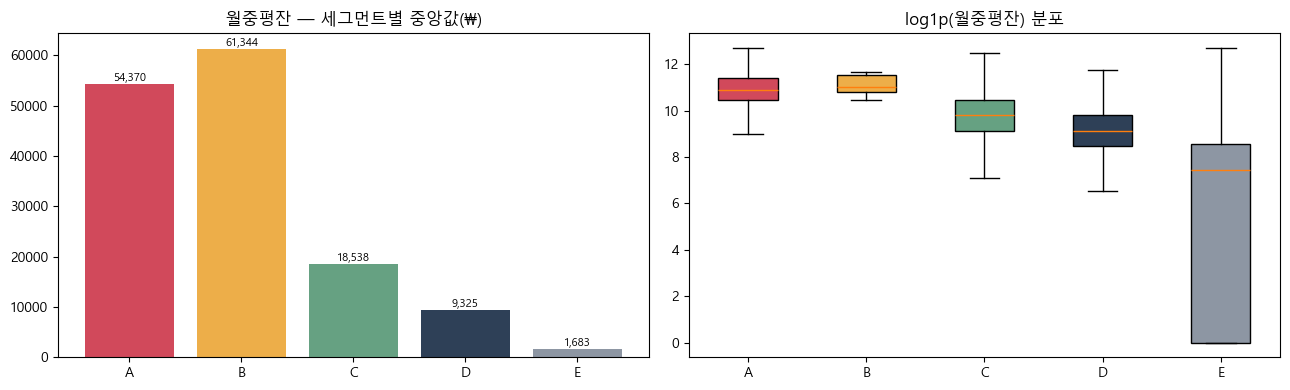

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
m1 = dfx.groupby('Segment')['월중평잔'].median().reindex(SEG_ORDER)
ax[0].bar(SEG_ORDER, m1.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title('월중평잔 — 세그먼트별 중앙값(₩)')
for i,v in enumerate(m1.values): ax[0].text(i,v,f'{v:,.0f}',ha='center',va='bottom',fontsize=8)
data=[np.log1p(dfx.loc[dfx['Segment']==s,'월중평잔'].clip(lower=0)) for s in SEG_ORDER]
bp=ax[1].boxplot(data, labels=SEG_ORDER, showfliers=False, patch_artist=True)
for p,s in zip(bp['boxes'],SEG_ORDER): p.set_facecolor(SEG_COLORS[s])
ax[1].set_title('log1p(월중평잔) 분포'); plt.tight_layout(); plt.show()

## 4. ★ 리볼빙(RV) 잔액 vs Segment — B 가설 검증

'B = 리볼빙 성향' 가설. RV 잔액이 B에서 유독 큰지 확인 (중앙값 + 보유율).

In [7]:
rv_cols = [c for c in ['RV_평균잔액_R12M','RV_최대잔액_R12M','RV_평균잔액_R6M','RV_평균잔액_R3M',
                       '월중평잔_RV일시불','잔액_리볼빙일시불이월_B0M','잔액_리볼빙CA이월_B0M'] if c in dfx]
print('=== RV 잔액 세그먼트별 중앙값 ===')
print(dfx.groupby('Segment')[rv_cols].median().reindex(SEG_ORDER).T.to_string())
print('\n=== RV 잔액 세그먼트별 평균 (0-inflated이라 평균도 확인) ===')
print(dfx.groupby('Segment')[rv_cols].mean().reindex(SEG_ORDER).round(0).T.to_string())
print('\n=== RV 보유율(%) : RV_평균잔액_R12M>0 비율 ===')
print((dfx.assign(rv=(dfx['RV_평균잔액_R12M']>0)).groupby('Segment')['rv'].mean().reindex(SEG_ORDER)*100).round(1).to_string())

=== RV 잔액 세그먼트별 중앙값 ===
Segment            A    B    C    D    E
RV_평균잔액_R12M     0.0  0.0  0.0  0.0  0.0
RV_최대잔액_R12M     0.0  0.0  0.0  0.0  0.0
RV_평균잔액_R6M      0.0  0.0  0.0  0.0  0.0
RV_평균잔액_R3M      0.0  0.0  0.0  0.0  0.0
월중평잔_RV일시불       0.0  0.0  0.0  0.0  0.0
잔액_리볼빙일시불이월_B0M  0.0  0.0  0.0  0.0  0.0
잔액_리볼빙CA이월_B0M   0.0  0.0  0.0  0.0  0.0

=== RV 잔액 세그먼트별 평균 (0-inflated이라 평균도 확인) ===


Segment               A       B       C       D      E
RV_평균잔액_R12M      652.0   441.0   845.0   990.0  340.0
RV_최대잔액_R12M     1271.0  1115.0  1376.0  1545.0  548.0
RV_평균잔액_R6M       520.0   470.0   687.0   801.0  290.0
RV_평균잔액_R3M       516.0   513.0   707.0   820.0  295.0
월중평잔_RV일시불       1958.0  2611.0  2151.0  2151.0  670.0
잔액_리볼빙일시불이월_B0M   570.0   886.0   667.0   754.0  274.0
잔액_리볼빙CA이월_B0M     38.0     0.0     0.0     7.0    3.0

=== RV 보유율(%) : RV_평균잔액_R12M>0 비율 ===
Segment
A     8.0
B     8.3
C     9.7
D    10.9
E     5.2


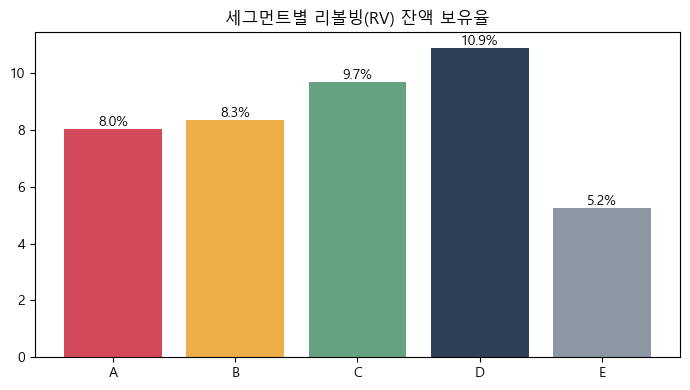

In [8]:
# RV 보유율 막대
rv_rate = (dfx.assign(rv=(dfx['RV_평균잔액_R12M']>0)).groupby('Segment')['rv'].mean().reindex(SEG_ORDER)*100)
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(SEG_ORDER, rv_rate.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
for i,v in enumerate(rv_rate.values): ax.text(i,v,f'{v:.1f}%',ha='center',va='bottom')
ax.set_title('세그먼트별 리볼빙(RV) 잔액 보유율'); plt.tight_layout(); plt.show()

## 5. 연체 잔액 vs Segment — B 위험 가설 검증

연체는 희귀 이벤트 → 평균(발생률) 기준.

In [9]:
dect = [c for c in ['연체잔액_B0M','연체원금_최근','연체원금_B1M'] if c in dfx]
print('=== 연체 지표 세그먼트별 평균 ===')
print(dfx.groupby('Segment')[dect].mean().reindex(SEG_ORDER).round(1).T.to_string())
# 연체 발생률: 연체잔액_B0M>0
print('\n=== 연체 발생률(%) : 연체잔액_B0M>0 ===')
print((dfx.assign(d=(dfx['연체잔액_B0M']>0)).groupby('Segment')['d'].mean().reindex(SEG_ORDER)*100).round(2).to_string())
# 연체일수_최근 결측아닌(=연체이력 있는) 비율
if '연체일수_최근' in dfx:
    print('\n=== 최근 연체이력 보유율(%) : 연체일수_최근 notna ===')
    print((dfx.assign(d=dfx['연체일수_최근'].notna()).groupby('Segment')['d'].mean().reindex(SEG_ORDER)*100).round(2).to_string())

=== 연체 지표 세그먼트별 평균 ===
Segment     A    B     C     D    E
연체잔액_B0M  0.0  0.0   0.9   0.9  0.9
연체원금_최근   0.0  0.0   7.6   7.5  5.2
연체원금_B1M  0.0  0.0  13.0  12.1  7.5

=== 연체 발생률(%) : 연체잔액_B0M>0 ===
Segment
A    0.00
B    0.00
C    0.04
D    0.04
E    0.04

=== 최근 연체이력 보유율(%) : 연체일수_최근 notna ===
Segment
A    0.00
B    0.00
C    0.28
D    0.38
E    3.09


## 6. Segment를 잘 가르는 수치형 피처 랭킹

In [10]:
drop=set(const_cols)|{'기준년월'}
num_cols=[c for c in dfx.columns if c not in drop and c not in ('ID','Segment') and pd.api.types.is_numeric_dtype(dfx[c])]
print('수치형 분석 대상:', len(num_cols))
med=dfx.groupby('Segment')[num_cols].median().reindex(SEG_ORDER).T
iqr=(dfx[num_cols].quantile(0.75)-dfx[num_cols].quantile(0.25)).replace(0,np.nan)
sep=((med.max(axis=1)-med.min(axis=1))/(iqr+1e-9)).sort_values(ascending=False)
def monotonic(row):
    v=row.values.astype(float); return np.all(np.diff(v)<=0) or np.all(np.diff(v)>=0)
med_sorted=med.loc[sep.index]; med_sorted.insert(0,'sep_score',sep.round(2))
med_sorted['monotonic']=med.loc[sep.index].apply(monotonic,axis=1)
print('분리도 상위 20:')
med_sorted.head(20)

수치형 분석 대상: 68


분리도 상위 20:


Segment,sep_score,A,B,C,D,E,monotonic
평잔_할부_3M,18.17,5462.5,21736.0,1010.0,646.0,0.0,False
잔액_할부_B1M,16.32,4309.0,20478.5,933.0,0.0,0.0,False
평잔_할부_6M,15.52,8601.5,24760.0,1466.0,961.0,0.0,False
월중평잔_할부,15.16,4139.5,17356.0,985.0,523.0,0.0,False
월중평잔_할부_B0M,14.48,4397.0,17451.5,1051.0,504.0,0.0,False
잔액_할부_B2M,12.89,4600.5,17345.0,1088.0,0.0,0.0,False
잔액_할부_B0M,10.20,4148.5,15622.5,0.0,0.0,0.0,False
월중평잔,7.65,54370.0,61343.5,18538.0,9325.0,1683.0,False
평잔_3M,7.32,48915.5,59509.5,18698.0,9446.0,1823.0,False
평잔_6M,6.43,61304.0,63758.5,22285.0,11356.0,2042.0,False


## 7. 소수클래스 A / B

In [11]:
glob_med=dfx[num_cols].median(); a_med=dfx[dfx['Segment']=='A'][num_cols].median(); b_med=dfx[dfx['Segment']=='B'][num_cols].median()
cmp=pd.DataFrame({'A_median':a_med,'B_median':b_med,'ALL_median':glob_med})
cmp['A_vs_B_absdiff']=(a_med-b_med).abs()
print('=== A vs B 차이 큰 피처 (분리 후보) ===')
print(cmp.sort_values('A_vs_B_absdiff',ascending=False).head(15).to_string())

=== A vs B 차이 큰 피처 (분리 후보) ===
               A_median  B_median  ALL_median  A_vs_B_absdiff
평잔_할부_3M         5462.5   21736.0         0.0         16273.5
잔액_할부_B1M        4309.0   20478.5         0.0         16169.5
평잔_할부_6M         8601.5   24760.0         0.0         16158.5
월중평잔_할부          4139.5   17356.0         0.0         13216.5
월중평잔_할부_B0M      4397.0   17451.5         0.0         13054.5
잔액_할부_B2M        4600.5   17345.0         0.0         12744.5
잔액_할부_B0M        4148.5   15622.5         0.0         11474.0
잔액_할부_무이자_B0M    4021.5   15294.5         0.0         11273.0
평잔_3M           48915.5   59509.5      2930.0         10594.0
평잔_일시불_3M       23981.5   13888.0      1700.0         10093.5
평잔_일시불_6M       25591.0   15722.0      1767.0          9869.0
월중평잔            54370.0   61343.5      2806.0          6973.5
월중평잔_일시불        24806.5   18697.0      1476.5          6109.5
잔액_일시불_B1M      19456.5   14808.5      1138.0          4648.0
잔액_일시불_B2M      18831.5   14486.5      

## 8. 요약 & 발견

### 잔액도 순서형 — 단, 상위는 B≈A (B가 미세 우위)
`월중평잔` 중앙값: **A 54,370 · B 61,344 · C 18,538 · D 9,325 · E 1,683**. C→E는 단조, 최상위는 A와 B가 사실상 동급(B가 약간 큼). 잔액은 소비/여신의 강한 프록시.

### ★★ 가장 큰 발견 — **B의 지문 = 할부(割賦) 잔액** (지금까지 중 가장 깨끗한 A/B 분리)
할부 잔액 계열이 **분리도 최상위(sep 10~18, 전체 1~7위 독식)**, 그리고 **B가 A의 약 4배**:
- `잔액_할부_B0M` 중앙값 **A 4,148 vs B 15,622** (C·D·E = 0)
- `평잔_할부_3M` **A 5,462 vs B 21,736**, `평잔_할부_6M` A 8,602 vs B 24,760
→ **B = 할부로 소비를 파이낸싱하는 고소비 고객.** 신용정보의 B 고금리도 이 할부/여신 이용과 일관. **A vs B를 가르는 가장 강력한 축.**

### ★ 가설 정정 — B는 '리볼빙'도 '연체'도 아니다
- **리볼빙(RV) 가설 기각**: RV 잔액 중앙값은 전 세그 0, 보유율은 오히려 **A/B가 최저(8.0/8.3%), C/D가 최고(9.7/10.9%)**. B는 리볼빙 고객이 아님.
- **연체 가설 기각**: 실제 연체잔액·연체일수 발생률이 **A·B 모두 0%**. 최근 연체이력 보유율은 **E가 최고(3.09%)**, A/B는 0. → 04에서 본 B의 `연체건수_R6M` 평균(0.708)은 실제 연체(overdue)로 이어지지 않음(경미한 결제지연 카운트로 추정). **B는 건전한 고소비·할부이용 고객**으로 재해석.

### 순서형 요약
잔액·평잔은 C·D·E 구간에서 깔끔한 단조. A/B는 규모로는 겹치고 **할부 잔액으로만 갈림**. E는 잔액 거의 0 + 유일하게 연체이력 존재(휴면/부실 혼재).

### 전처리 메모
- **상수 컬럼 13개** 제거(연체잔액 해외/카드론/대환론, RV잔액이월횟수, 매각잔액 등 이 표본 전부 0).
- 센티넬: 연체일수 `-999999`·최종연체회차 `-99` → NaN. `연체일자_B0M`(99.9% 결측)=연체희귀.
- 잔액 컬럼 다수 0-inflated(특히 할부/카드론/RV) → 보유 플래그 + 값 분리 인코딩.

**다음 카테고리**: 6.채널정보 (접촉 채널 활동량).